## Imports

In [1]:
import numpy as np
import xarray as xr
import copy
import src.utils
import src.lme_utils
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cmocean
import os
import pathlib
import cartopy.crs as ccrs
import pandas as pd
import scipy.stats
import tqdm
import time
import xesmf as xe

## Set seaborn plotting style
sns.set(rc={"axes.facecolor": "white", "axes.grid": False})
sns.set_palette("colorblind")

## initialize RNG
rng = np.random.default_rng(seed=100)

## Funcs

In [2]:
## specify lons/lats for E/W boxes
LONS_W = [120, 200]
LONS_E = [200, 280]


## funcs to plot boxes
def plot_wbox(ax, **kwargs):
    src.utils.plot_box(ax, lons=LONS_W, lats=[-5, 5], **kwargs)


def plot_ebox(ax, **kwargs):
    src.utils.plot_box(ax, lons=LONS_E, lats=[-5, 5], **kwargs)


## funcs to average over regions
def get_eq_avg(data, lons):
    """average over equatorial region and longitudes"""
    return data.sel(longitude=slice(*lons), latitude=slice(-5, 5)).mean(
        ["longitude", "latitude"]
    )


def get_e(data):
    return get_eq_avg(data, LONS_E)


def get_w(data):
    return get_eq_avg(data, LONS_W)


def get_dx(data):
    return get_e(data) - get_w(data)


def add_gridlines(axs):
    """func to add gridlines to axs object"""

    for ax in axs[:-1, 0]:
        ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            linewidth=1,
            alpha=0,
            xlocs=[],
            ylocs=[-30, 0, 30],
        )
    for ax in axs[-1]:
        gl_ = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            linewidth=1,
            alpha=0,
            xlocs=[50, 120 - 160],
            # xlocs=[],
            ylocs=[-30, 0, 30],
        )
        gl_.top_labels = False
        # gl_.bottom_labels = True
    # gl_.left_labels = False

    return


def plot_level(ax, data, level, ls="-", c="white"):
    """plot single level on hovmoller"""
    ax.contour(
        data.longitude,
        data.latitude,
        data,
        levels=[level],
        colors=c,
        linestyles=ls,
        zorder=10,
        transform=ccrs.PlateCarree(),
    )
    return


import cartopy.crs as ccrs


def make_cb_range(dx, nlevs):
    amp = dx * nlevs - dx / 2

    lev1 = np.arange(0, amp + dx / 2, dx) + dx / 2
    lev0 = -lev1[::-1]
    return np.concatenate([lev0, lev1])


def plot_pr_diff(ax, data, dx=0.2, nlev=5):
    """plot data on ax"""

    cp = ax.contourf(
        data.longitude,
        data.latitude,
        data,
        cmap="cmo.balance_r",
        levels=make_cb_range(dx, nlev),
        transform=ccrs.PlateCarree(),
        extend="both",
    )

    return cp


def plot_sst_sigma(ax, data, lev_min=0.3, dx=0.2, nlev=5):
    """plot data on ax"""

    cp = ax.contourf(
        data.longitude,
        data.latitude,
        data,
        cmap="cmo.amp",
        levels=np.arange(lev_min, lev_min + dx * (nlev + 1), dx),
        transform=ccrs.PlateCarree(),
        extend="both",
    )

    return cp


def plot_pr(ax, data, lev_min=1, dx=1, nlev=5):
    """plot data on ax"""

    cp = ax.contourf(
        data.longitude,
        data.latitude,
        data,
        cmap="cmo.rain",
        levels=np.arange(lev_min, lev_min + dx * (nlev + 1), dx),
        transform=ccrs.PlateCarree(),
        extend="both",
    )

    return cp

## Data loading

In [3]:
def sel_area(data, lon_range=None, lat_range=None):
    """select area on t grids"""

    ## find in lon range
    if lon_range is None:
        lon_idx = np.array([True for _ in data.nlon])
    else:
        lon_idx = (
            ((data.TLONG >= lon_range[0]) & (data.TLONG <= lon_range[1]))
            .any("nlat")
            .values
        )

    if lat_range is None:
        lat_idx = np.array([True for _ in data.nlat])
    else:
        lat_idx = (
            ((data.TLAT >= lat_range[0]) & (data.TLAT <= lat_range[1]))
            .any("nlon")
            .values
        )

    return data.isel(nlon=lon_idx, nlat=lat_idx)


def area_avg(data, varname, lon_range=None, lat_range=None):
    """average over area"""

    ## trim data
    data_ = sel_area(data, lon_range=lon_range, lat_range=lat_range)

    ## get dims to sum over
    integrate = lambda x: (x * data_["dA"]).sum(["nlon", "nlat"])

    return integrate(data_[varname]) / integrate(1.0)


def get_eli_helper(exceeds_thresh):
    """compute ELI from mask of threshold exceedance"""

    ## sum and count longitudes exceeding thresh
    lon = exceeds_thresh.longitude
    longitude_sum = (exceeds_thresh * lon).sum(["longitude", "latitude"])
    longitude_count = exceeds_thresh.sum(["longitude", "latitude"])

    ## eli is average longitude
    eli = longitude_sum / longitude_count

    return eli


def get_eli(rsst, rsst_thresh=0, max_lat=15):
    """compute ELI from tropical SST data"""

    ## get equatorial Pac. SST
    rsst_pac = rsst.sel(longitude=slice(120, 280), latitude=slice(-max_lat, max_lat))

    ## get boolean array where SST exceeds thresh
    exceeds_thresh0 = rsst_pac >= rsst_thresh

    ## compute initial ELI estimate
    eli0 = get_eli_helper(exceeds_thresh0)

    return eli0

## Load the data

### init. cluster

In [4]:
from dask.distributed import LocalCluster, Client

cluster = LocalCluster(n_workers=2)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kcarr/ro-change/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kcarr/ro-change/proxy/8787/status,Workers: 2
Total threads: 2,Total memory: 72.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41439,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kcarr/ro-change/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42337,Total threads: 1
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kcarr/ro-change/proxy/45655/status,Memory: 36.00 GiB
Nanny: tcp://127.0.0.1:35937,


### do loading

In [5]:
SAVE_FP = pathlib.Path("/glade/work/kcarr/lme_data/snr")
SAVE_FNAME = SAVE_FP / "pr_split.nc"

## load precip
pr = xr.open_dataset(SAVE_FNAME).compute()
pr = pr.rename({"lon": "longitude", "lat": "latitude"})

# ## convert m/s to mm/day
# mm_per_m = 1e3
# s_per_day = 24 * 60 * 60
# pr *= mm_per_m * s_per_day

## Analysis

In [6]:
## get climatology
get_clim = lambda x: x["forced"].groupby("time.month").mean(["time"])
clim = get_clim(pr.isel(time=slice(None, 360)))

clim_fma = clim.sel(month=[2, 3, 4]).mean("month")
clim_aso = clim.sel(month=[8, 9, 10]).mean("month")

### Spatial plot

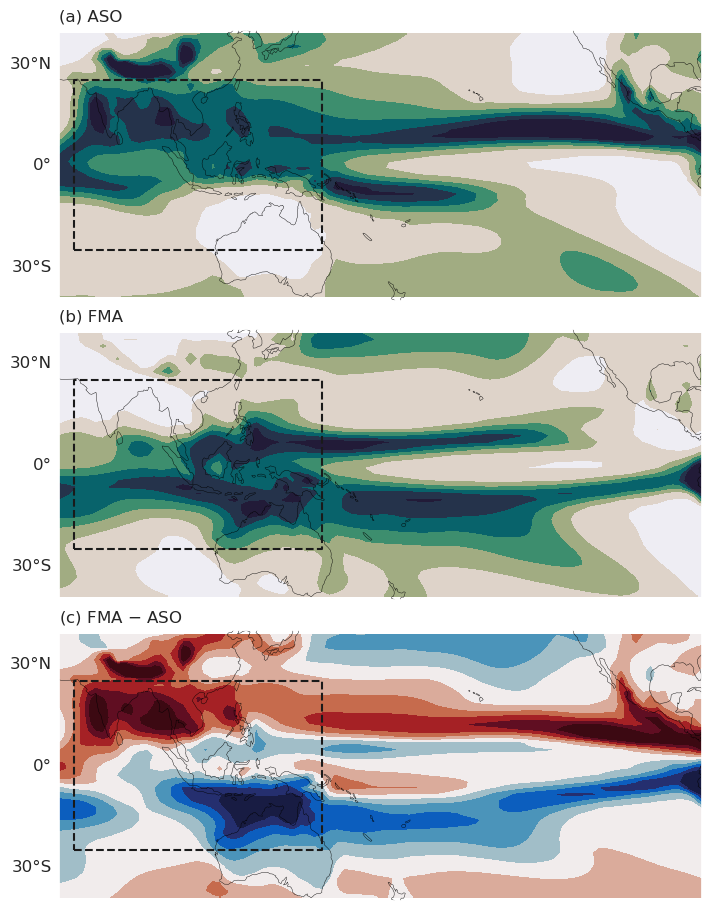

In [7]:
## specify intervals
dxs = np.array([2])

fig = plt.figure(figsize=(7, 9), layout="constrained")
format_func = lambda ax,: src.utils.plot_setup_pac(ax, max_lat=40, lon_range=(60, 280))
axs = src.utils.subplots_with_proj(fig, nrows=3, ncols=1, format_func=format_func)


cp00 = plot_pr(axs[0, 0], clim_aso, dx=2)
cp00 = plot_pr(axs[1, 0], clim_fma, dx=2)
cp00 = plot_pr_diff(axs[2, 0], clim_fma - clim_aso, dx=2)

## label
axs[0, 0].set_title("(a) ASO", loc="left")
axs[1, 0].set_title("(b) FMA", loc="left")
axs[2, 0].set_title(r"(c) FMA $-$ ASO", loc="left")

## add labels
# add_gridlines(axs)
bbox = dict(boxstyle="round", facecolor="white", alpha=1)
legend_kwargs = dict(x=0.01, y=0.02, fontdict=dict(size=12, color="gray"), bbox=bbox)
for ax in axs.flatten():
    ax.set_aspect("auto")
    src.utils.plot_box(ax, lons=[65, 150], lats=[-25, 25], c="k", ls="--")

## colorbars
cb_kwargs = dict(label=r"$^{\circ}$C", pad=0.03)
# fig.colorbar(cp00, ax=axs[0,0], ticks=[-3.6,0,3.6], **cb_kwargs)
# fig.colorbar(cp10, ax=axs[1,0], ticks=[-1.8,0,1.8], **cb_kwargs)
add_gridlines(axs)
plt.show()

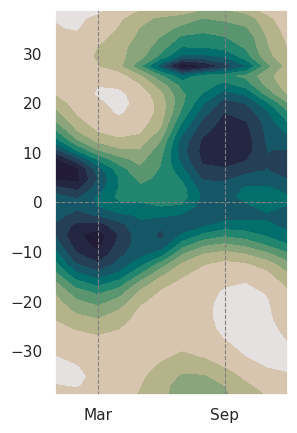

In [8]:
## average over longitudes in australia/Asia
clim_meri = clim.sel(longitude=slice(65, 140)).mean("longitude")

fig, ax = plt.subplots(figsize=(3, 5))
ax.contourf(
    clim_meri.month,
    clim_meri.latitude,
    clim_meri.transpose("latitude", "month"),
    cmap="cmo.rain",
    extend="both",
    levels=np.arange(0, 11, 1),
)

# ax.set_ylim([-25,25])

src.utils.add_vticks([ax], xlines=[3, 9], xticks=[])
ax.set_xticks([3, 9], labels=["Mar", "Sep"])
ax.axhline(0, ls="--", c="gray", lw=0.8)

plt.show()

## Look at variability

### Seasonal cycle

In [9]:
lon_range = slice(65, 140)
pr_meri = pr.sel(longitude=lon_range).mean("longitude")
pr_s = pr_meri.sel(latitude=slice(-25, -5)).mean("latitude")
pr_eq = pr_meri.sel(latitude=slice(-5, 5)).mean("latitude")
pr_n = pr_meri.sel(latitude=slice(5, 25)).mean("latitude")
# pr_idx = xr.merge([pr_s.rename("s"), pr_n.rename("n")])

In [10]:
def fill_between_months(ax, m0, m1):
    """shade month range"""

    ## get bounds for plot
    N = 10
    yrange = ax.get_ylim()

    ## get bounds for plot
    y = np.linspace(*yrange, N)
    x1 = (m0 - 0.2) * np.ones(N)
    x2 = (m1 + 0.2) * np.ones(N)

    ## plot
    ax.fill_betweenx(y=y, x1=x1, x2=x2, color="gray", edgecolor="white", alpha=0.2)

    return

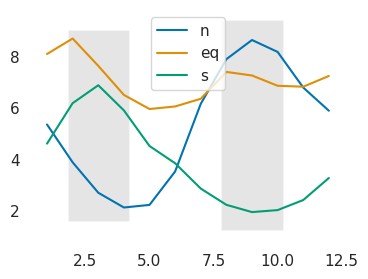

In [11]:
fig, ax = plt.subplots(figsize=(4, 3))

## plot data
for r, l in zip([pr_n, pr_eq, pr_s], ["n", "eq", "s"]):
    ax.plot(np.arange(1, 13), get_clim(r), label=l)

## should seasons
fill_between_months(ax, 2, 4)
fill_between_months(ax, 8, 10)
ax.legend()

plt.show()

In [12]:
resamp_ = lambda x: x.resample({"time": "QS-FEB"}).mean()
# pr_idx_ = pr_idx.resample({"time": "QS-FEB"}).mean()

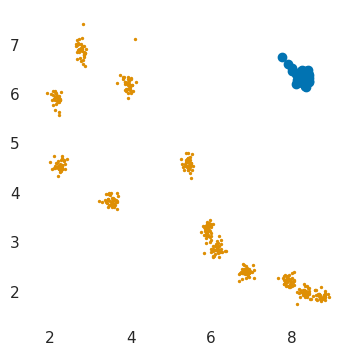

In [13]:
fig, ax = plt.subplots(figsize=(4, 4))

# ax.scatter(
#     pr_idx_["n"].isel(time=slice(2,2+480,None)),
#     pr_idx_["s"].isel(time=slice(2,2+480,None)),
#     s=2,
# )

ax.scatter(
    resamp_(pr_n["forced"]).isel(time=slice(2, 2 + 480, 4)),
    resamp_(pr_s["forced"]).isel(time=slice(4, 4 + 480, 4)),
    # s=2,
)

ax.scatter(
    pr_n["forced"].isel(time=slice(None, 480)),
    pr_s["forced"].isel(time=slice(None, 480)),
    s=2,
)

plt.show()

### forced change over time

In [14]:
## 1. hovmoller of N. hemisphere precip/seasonal cycle (cyc. vs. time)
## 2. "" (lat vs. time for given season)

In [15]:
pr_meri_seasonal = pr_meri.resample({"time": "QS-FEB"}).mean()

In [16]:
def get_forced(x):
    """get forced signal"""

    ## trim data to remove NaNs
    return x["forced"]

In [17]:
## get forced signal
pr_meri_forced = pr_meri["forced"]

## resample to seasonal
pr_meri_seasonal = pr_meri_forced.resample({"time": "QS-FEB"}).mean()

plot aboslute diff

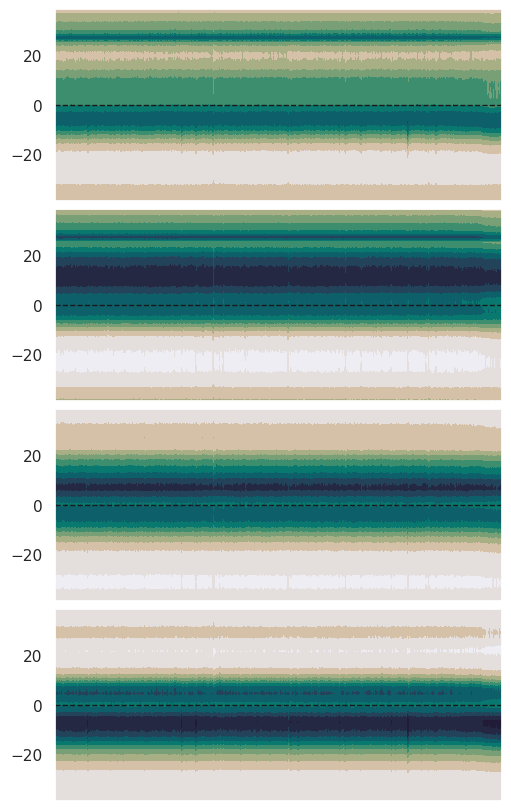

In [18]:
fig, axs = plt.subplots(4, 1, figsize=(5, 8), layout="constrained")

for ax, t_start_idx in zip(
    axs,
    [1, 2, 3, 4],
):

    ## get plot data
    pdata = pr_meri_seasonal.isel(
        time=slice(t_start_idx, None, 4),
    )

    ## update time coord
    pdata = pdata.assign_coords({"time": pdata.time.dt.year.values})
    pdata = pdata.transpose("latitude", ...)

    ## plot data
    ax.contourf(
        pdata.time,
        pdata.latitude,
        pdata,
        levels=np.arange(1, 11, 1),
        cmap="cmo.rain",
        extend="both",
    )

    ax.set_xticks([])
    ax.axhline(0, ls="--", c="k", lw=1)

plt.show()

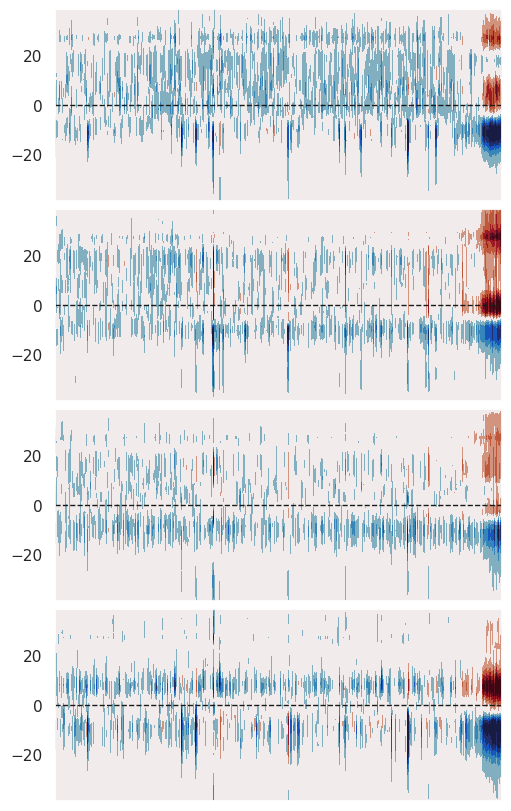

In [19]:
delta = lambda x: x - x.isel(time=slice(50, 150)).mean("time")

fig, axs = plt.subplots(4, 1, figsize=(5, 8), layout="constrained")

for ax, t_start_idx in zip(
    axs,
    [1, 2, 3, 4],
):

    ## get plot data
    pdata = pr_meri_seasonal.isel(
        time=slice(t_start_idx, None, 4),
    )

    ## update time coord
    pdata = pdata.assign_coords({"time": pdata.time.dt.year.values})
    pdata = pdata.transpose("latitude", ...)

    ## plot data
    ax.contourf(
        pdata.time,
        pdata.latitude,
        delta(pdata),
        levels=src.utils.make_cb_range(0.5, 0.1),
        cmap="cmo.balance_r",
        extend="both",
    )

    ax.set_xticks([])
    ax.axhline(0, ls="--", c="k", lw=1)

plt.show()

In [20]:
volc_forcing = src.lme_utils.load_volc_forcing(cutoff=25)

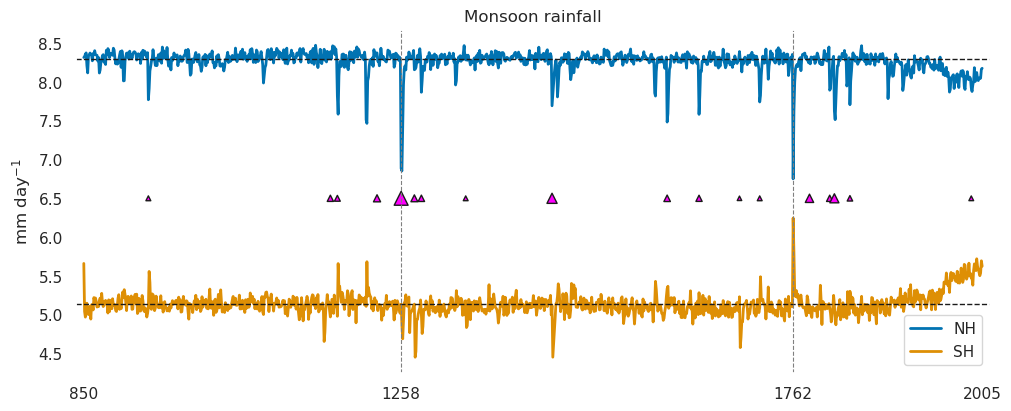

In [21]:
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")

for idx, js, offset, la in zip([pr_n, pr_s], [2, 0], [0, -1.2], ["NH", "SH"]):

    ## get data
    data_ = resamp_(idx["forced"]).isel(time=slice(js, None, 4)) + offset
    yr = data_.time.dt.year

    ## plot data
    ax.plot(yr, data_, label=la, lw=2)

    ## plot climatological value
    clim_ = data_.sel(time=slice("0900-01", "0999-12")).mean("time")
    ax.axhline(clim_, ls="--", c="k", lw=1)


## plot volc data
ax.scatter(
    volc_forcing.year,
    6.5 * xr.ones_like(volc_forcing.year),
    s=volc_forcing["Global_norm"] * 100,
    marker="^",
    c="magenta",
    edgecolor="k",
)

ax.legend()
ax.set_title("Monsoon rainfall")

## formatting
ax.set_xlim([840, 2015])
ax.set_ylabel(r"mm day$^{-1}$")
src.utils.add_vticks([ax], xlines=[1258, 1762], xticks=[850, 1258, 1762, 2005])

plt.show()

### EOFs

In [22]:
def unstack_season(x):
    """unstack season"""
    x_ = src.utils.unstack_month_and_year(x)

    ## rename
    x_["season"] = xr.DataArray(
        ["FMA", "MJJ", "ASO", "NDJ"],
        coords=dict(month=x_.month),
    )

    return x_.swap_dims({"month": "season"}).drop_vars("month")


def prep(y):
    """prepare data for EOF analysis"""

    ## resample to seasonal
    y_ = y.resample({"time": "QS-FEB"}).mean()

    ## find months
    is_aso = y_.time.dt.month == 8
    is_ndj = y_.time.dt.month == 11
    is_fma = y_.time.dt.month == 2
    in_range = is_aso.values | is_ndj.values | is_fma.values

    ## subset for data
    y_ = y_.isel(time=in_range).isel(time=slice(1, -2))

    ## get year start
    yrs = y_.time.dt.year.values
    mths = y_.time.dt.month.values
    year_start = np.array([y - 1 if (m == 2) else y for (y, m) in zip(yrs, mths)])

    ## get season
    season_dict = {2: "FMA", 8: "ASO", 11: "NDJ"}
    season = np.array([season_dict[m] for m in mths])

    ## create multi-index
    new_idx = pd.MultiIndex.from_arrays([year_start, season], names=["y0", "season"])

    ## convert to xr
    new_idx_xr = xr.Coordinates.from_pandas_multiindex(new_idx, dim="time")

    ## add to original data
    y_ = y_.assign_coords(new_idx_xr)

    return y_.unstack("time")

In [23]:
## get anoms and resample to seasonal
pr_meri_anom = pr_meri["anom"]

X_ = prep(pr_meri_anom)
X_clim = prep(pr_meri_forced).mean("y0")

In [24]:
import xeofs as xe

## specs for EOFs
eofs_kwargs = dict(n_modes=10, standardize=False, use_coslat=True, center=True)

## initialize EOF model
eofs = xe.single.EOF(**eofs_kwargs)

## compute
eofs.fit(X_, dim=["y0", "member"])

normalize so scores have unit standard dev.

True


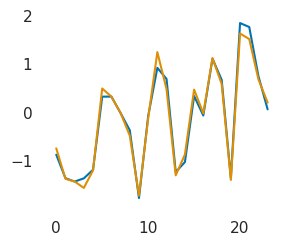

In [25]:
## get number of samples
N = int(len(X_.y0) * len(X_.member))

## do normalization
scores_norm = eofs.scores(normalized=True) * np.sqrt(N)
comps = eofs.components(normalized=True) * np.sqrt(eofs.explained_variance())

## check normalization
print(np.allclose(np.ones(10), (scores_norm).std(["member", "y0"]).values))

## check reconstruction
fn = lambda x: x.sel(latitude=slice(-25, 0)).mean(["latitude"]).sel(season="ASO")
idx = dict(member=0, y0=slice(None, 24))

fig, ax = plt.subplots(figsize=(3, 2.5))
ax.plot(fn(X_).isel(idx))
ax.plot((fn(comps) * scores_norm.isel(idx)).sum("mode"))
plt.show()

#### Get climatology

To-do: plot sum and difference of AMJ/FMA

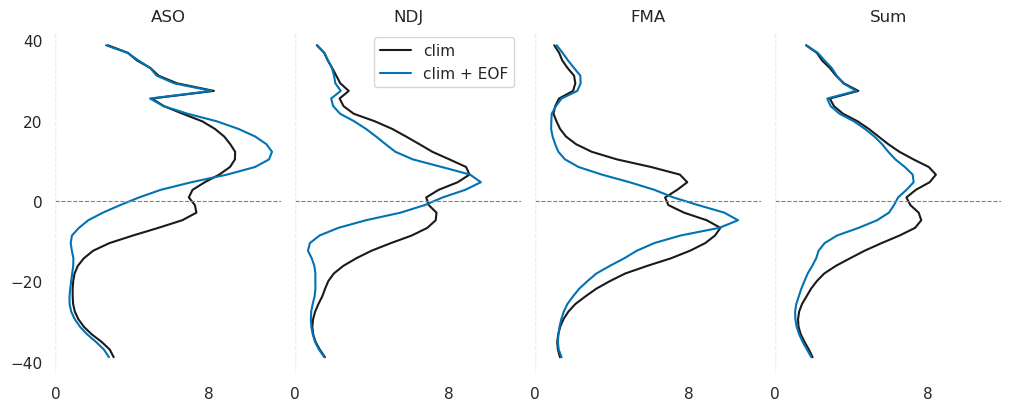

In [26]:
# specify EOF scale
EOF_SCALE = -2

## get total
total = X_clim + EOF_SCALE * comps.isel(mode=0)

clim_sum = X_clim.mean("season")
eof_sum = comps.sum("season")

fig, axs = plt.subplots(1, 4, figsize=(10, 4), layout="constrained")

for ax, s in zip(axs, ["ASO", "NDJ", "FMA"]):

    ax.set_title(s)

    ## plot clim
    ax.plot(X_clim.sel(season=s), comps.latitude, c="k", label="clim")

    ## plot clim + eof
    # sum_ = X_clim.sel(season=s) + EOF_SCALE * comps.sel(season=s).isel(mode=0)
    ax.plot(total.sel(season=s), comps.latitude, label="clim + EOF")

    # plot EOF
    # ax.plot(4 * comps.isel(mode=0).sel(season=s), comps.latitude)

## plot sum over seasons
axs[-1].plot(X_clim.mean("season"), comps.latitude, c="k", label="clim")
axs[-1].plot(total.mean("season"), comps.latitude)

for ax in axs:
    ax.set_yticks([])
    ax.axhline(0, ls="--", c="gray", lw=0.8)


axs[-1].set_title("Sum")
axs[1].legend()
axs[0].set_yticks([-40, -20, 0, 20, 40])
src.utils.add_vticks(axs, xlines=[0], xticks=[0, 8])
src.utils.set_lims(axs)

Look at sum/difference

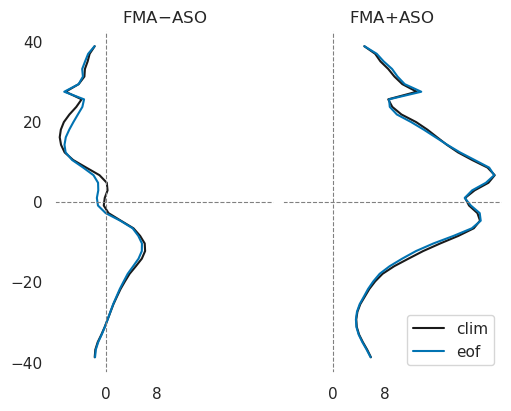

In [27]:
## funcs to get sum/diff
get_diff = lambda x: x.sel(season="FMA") - x.sel(season="ASO")
# get_sum = lambda x : x.sel(season="FMA") + x.sel(season="NDJ") + x.sel(season="ASO")
# get_sum = lambda x : x.sel(season="NDJ")
get_sum = lambda x: x.sum("season")

## difference/sum in clim
dX_clim = get_diff(X_clim)
sum_clim = get_sum(X_clim)

## difference/sum in eof
dX_eof = EOF_SCALE * get_diff(comps).isel(mode=3)
sum_eof = EOF_SCALE * get_sum(comps).isel(mode=3)

fig, axs = plt.subplots(1, 2, figsize=(5, 4), layout="constrained")

for ax, clim_, eof_ in zip(axs, [dX_clim, sum_clim], [dX_eof, sum_eof]):

    ## plot clim
    ax.plot(clim_, comps.latitude, c="k", label="clim")

    ## plot clim + eof
    # sum_ = X_clim.sel(season=s) - 2 * comps.sel(season=s).isel(mode=2)
    ax.plot(clim_ + eof_, eof_.latitude, label="eof")

    # plot EOF
    # ax.plot(4 * comps.isel(mode=0).sel(season=s), comps.latitude)

    ax.set_yticks([])
    ax.axhline(0, ls="--", c="gray", lw=0.8)
    ax.set_title(s)

axs[1].legend()
axs[0].set_yticks([-40, -20, 0, 20, 40])
axs[0].set_title(r"FMA$-$ASO")
axs[1].set_title(r"FMA$+$ASO")
src.utils.add_vticks(axs, xlines=[0], xticks=[0, 8])
src.utils.set_lims(axs)

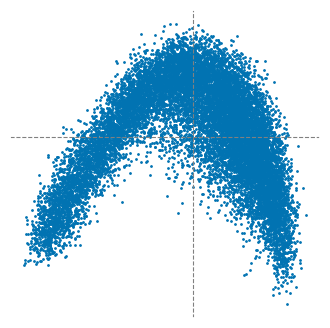

In [28]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(
    eofs.scores().isel(mode=0),
    eofs.scores().isel(mode=1),
    s=1,
)

src.utils.add_axes([ax])


plt.show()

#### Compare to Shawn's index

In [29]:
SAVE_FP = pathlib.Path("/glade/work/kcarr/lme_data")

## load and rename to match
aam = xr.open_dataarray(SAVE_FP / "trb_index_lme.nc")
aam = aam.rename({"time": "y0", "ens": "member"})

## get scores to match aam
scores_ = scores_norm.sel(y0=aam.y0)
scores_ = scores_.transpose(*aam.dims, "mode")

## merge
Z = xr.merge([scores_.rename("scores"), aam.rename("aam")])

To-do: compute low-pass filter before computing EOFs?

(900.0, 1100.0)

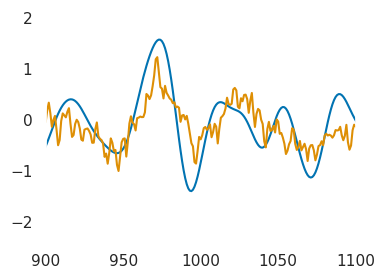

In [30]:
smoothed_mean = Z["scores"].rolling({"y0": 25}, center=True).mean()

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(Z.y0, Z["aam"].isel(member=0))
# ax.plot(Z.y0, Z["scores"].isel(member=0, mode=0))

ax.plot(Z.y0, 3 * smoothed_mean.isel(member=0, mode=0))

ax.set_xlim([900, 1100])

Note there is going to be a strong rectification effect:

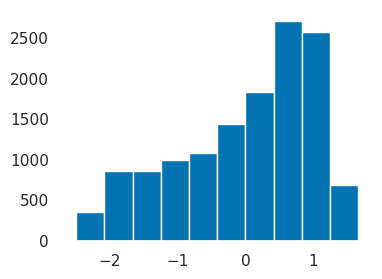

In [31]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(Z["scores"].isel(mode=0).values.flatten())
plt.show()

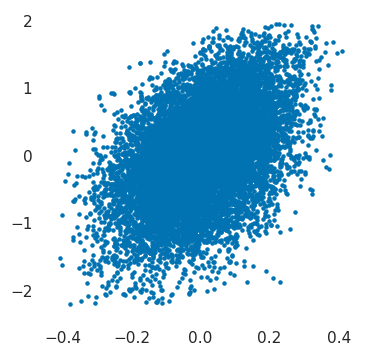

[ 0.4610693  -0.44797302 -0.00851348 -0.32884146 -0.06828394 -0.19475854
 -0.0726831   0.24375539  0.04631525  0.1550661 ]


In [32]:
get = lambda x: x.values.flatten()

fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(
    # get(Z["scores"].isel(mode=0)),
    get(smoothed_mean.isel(mode=0)),
    get(Z["aam"]),
    s=5,
)

plt.show()

## print out correlation with each mode
print(xr.corr(smoothed_mean, Z["aam"], dim=["y0", "member"]).values)

### Look at SST pattern

#### Load data

In [33]:
SAVE_FP = pathlib.Path("/glade/work/kcarr/lme_data/snr")
SAVE_FNAME = SAVE_FP / "sst_split.nc"

## load sst
sst = xr.open_dataset(SAVE_FNAME).compute()
sst = sst.rename({"lon": "longitude", "lat": "latitude"})

## get forced, anom signal
sst_forced = sst["forced"]
sst_anom = sst["anom"]

## apply preprocessing ot SST
X_sst = prep(sst_anom).sel(y0=scores_norm.y0)

## get forced, anom signal
pr_forced = pr["forced"]
pr_anom = pr["anom"]

## apply preprocessing ot SST
X_pr = prep(pr_anom).sel(y0=scores_norm.y0)

/glade/derecho/scratch/kcarr/tmp/ipykernel_20066/664428688.py:5: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  sst = xr.open_dataset(SAVE_FNAME).compute()


#### Compute

In [34]:
def regress_pinv(X, Y):
    """do linear regression"""

    ## prep data
    # prep = lambda x: x.transpose("member", ...)

    X_ = X.stack(s=["y0", "member"]).transpose("mode", "s")
    Y_ = Y.stack(s=["y0", "member"]).transpose("season", "latitude", "longitude", "s")

    ## empty array to hold results
    M = xr.DataArray(
        coords={
            "season": Y.season,
            "latitude": Y.latitude,
            "longitude": Y.longitude,
            "mode": X.mode,
        },
        dims=["season", "latitude", "longitude", "mode"],
    )

    ## do regression

    X_pinv = np.linalg.pinv(X_.values)
    M.values = np.einsum("...i,...ij->...j", Y_.values, X_pinv)

    return M

In [35]:
sst_patterns = regress_pinv(X=scores_norm, Y=X_sst)
pr_patterns = regress_pinv(X=scores_norm, Y=X_pr)

In [36]:
sst_patterns_aam = regress_pinv(
    X=aam.expand_dims({"mode": [0]}), Y=X_sst.sel(y0=aam.y0)
)
pr_patterns_aam = regress_pinv(X=aam.expand_dims({"mode": [0]}), Y=X_pr.sel(y0=aam.y0))

#### Plot

In [37]:
def plot_sst(ax, data, lev_min=1, dx=1, nlev=5):
    """plot data on ax"""

    cp = ax.contourf(
        data.longitude,
        data.latitude,
        data,
        cmap="cmo.balance",
        levels=make_cb_range(dx, nlev),
        transform=ccrs.PlateCarree(),
        extend="both",
    )

    return cp

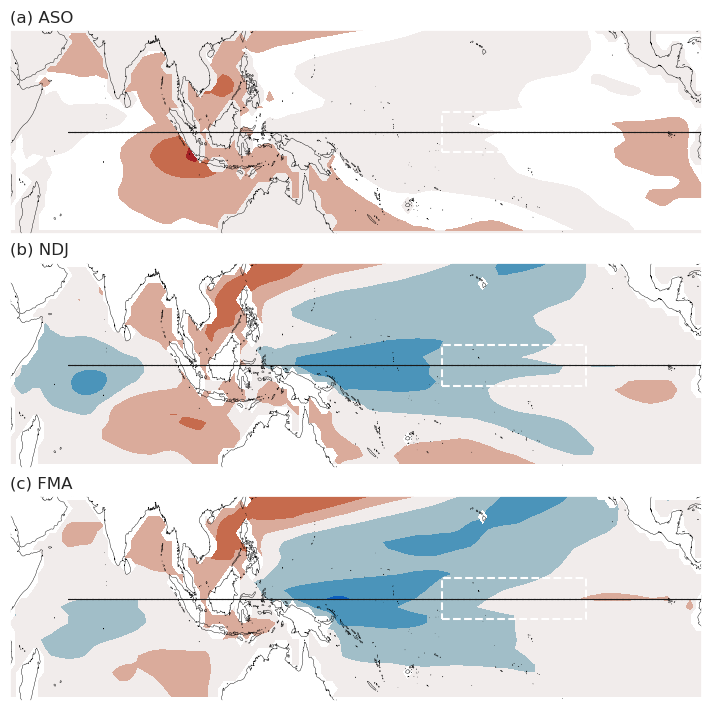

In [39]:
## specify plot data and interval
# p, DX = -sst_patterns.isel(mode=0), 0.25
p, DX = sst_patterns_aam.isel(mode=0), 0.1


fig = plt.figure(figsize=(7, 7), layout="constrained")
format_func = lambda ax,: src.utils.plot_setup_pac(ax, max_lat=25, lon_range=(40, 280))
axs = src.utils.subplots_with_proj(fig, nrows=3, ncols=1, format_func=format_func)


cp00 = plot_sst(axs[0, 0], p.sel(season="ASO"), dx=DX)
cp10 = plot_sst(axs[1, 0], p.sel(season="NDJ"), dx=DX)
cp20 = plot_sst(axs[2, 0], p.sel(season="FMA"), dx=DX)
# cp10 = plot_sst(axs[1, 0], clim_fma, dx=2)
# cp20 = plot_sst(axs[2, 0], clim_aso - clim_fma, dx=2)

## label
axs[0, 0].set_title("(a) ASO", loc="left")
axs[1, 0].set_title("(b) NDJ", loc="left")
axs[2, 0].set_title("(c) FMA", loc="left")

## add labels
# add_gridlines(axs)
bbox = dict(boxstyle="round", facecolor="white", alpha=1)
legend_kwargs = dict(x=0.01, y=0.02, fontdict=dict(size=12, color="gray"), bbox=bbox)
for ax in axs.flatten():
    ax.set_aspect("auto")
    src.utils.plot_box(ax, lons=[190, 240], lats=[-5, 5], c="w", ls="--")
    src.utils.plot_box(ax, lons=[60, 280], lats=[-1e-3, 1e-3], c="k", ls="--", lw=0.8)

## colorbars
cb_kwargs = dict(label=r"$^{\circ}$C", pad=0.03)
plt.show()

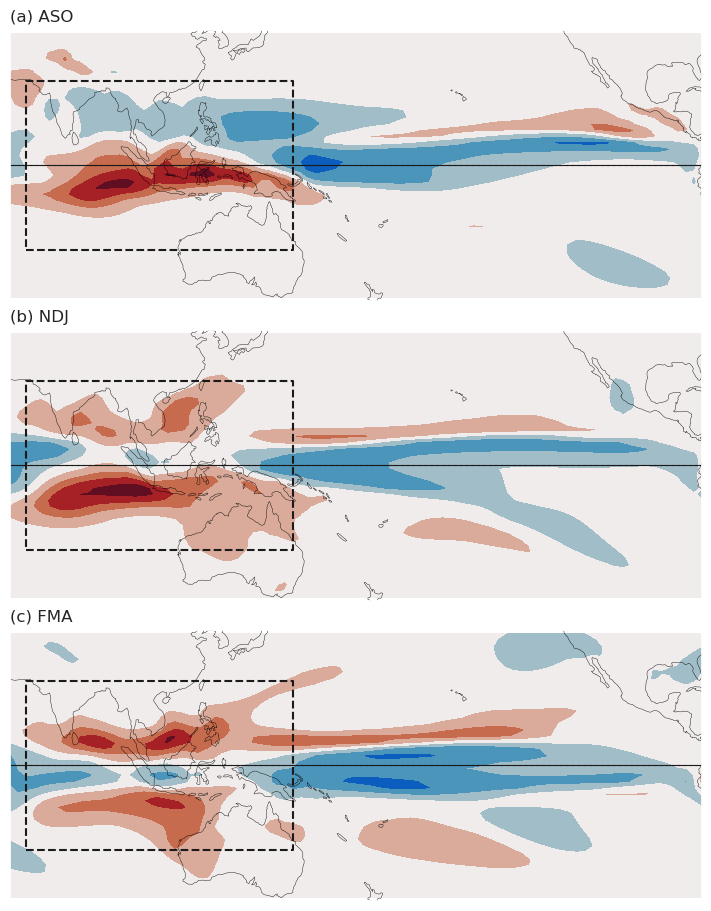

In [40]:
## specify plot data
p = -pr_patterns.isel(mode=0)
# p = -2*pr_patterns.isel(mode=2)
# p = 4*pr_patterns_aam.isel(mode=0)

## specify intervals
dxs = np.array([2])

fig = plt.figure(figsize=(7, 9), layout="constrained")
format_func = lambda ax,: src.utils.plot_setup_pac(ax, max_lat=40, lon_range=(60, 280))
axs = src.utils.subplots_with_proj(fig, nrows=3, ncols=1, format_func=format_func)


cp00 = plot_pr_diff(axs[0, 0], p.sel(season="ASO"), dx=1)
cp10 = plot_pr_diff(axs[1, 0], p.sel(season="NDJ"), dx=1)
cp20 = plot_pr_diff(axs[2, 0], p.sel(season="FMA"), dx=1)
# cp10 = plot_sst(axs[1, 0], clim_fma, dx=2)
# cp20 = plot_sst(axs[2, 0], clim_aso - clim_fma, dx=2)

## label
axs[0, 0].set_title("(a) ASO", loc="left")
axs[1, 0].set_title("(b) NDJ", loc="left")
axs[2, 0].set_title("(c) FMA", loc="left")

## add labels
# add_gridlines(axs)
bbox = dict(boxstyle="round", facecolor="white", alpha=1)
legend_kwargs = dict(x=0.01, y=0.02, fontdict=dict(size=12, color="gray"), bbox=bbox)
for ax in axs.flatten():
    ax.set_aspect("auto")
    src.utils.plot_box(ax, lons=[65, 150], lats=[-25, 25], c="k", ls="--")
    src.utils.plot_box(ax, lons=[60, 280], lats=[-1e-3, 1e-3], c="k", ls="--", lw=0.8)

## colorbars
cb_kwargs = dict(label=r"$^{\circ}$C", pad=0.03)
plt.show()

### Try taking monsoon precip together...

In [41]:
def stitch_monsoon(Y):
    """stitch together monsoon precip from each hemisphere"""

    ## get seasonal totals
    Y_ = prep(Y)

    ## get NH/SH precip
    NH_pr = Y_.sel(season="ASO", latitude=slice(0, None)).drop_vars("season")
    SH_pr = Y_.sel(season="FMA", latitude=slice(None, -0.1)).drop_vars("season")

    ## stitch
    monsoon_pr = xr.concat([SH_pr, NH_pr], dim="latitude")

    return monsoon_pr

In [42]:
Y = stitch_monsoon(pr_meri_anom).sel(y0=slice(900, 1850))
Y_clim = stitch_monsoon(pr_meri_forced).sel(y0=slice(900, 1850)).mean("y0")


# Y = prep(pr_meri_anom).mean("season")
# Y_clim = prep(pr_meri_forced).mean("season").sel(y0=slice(900,1850)).mean("y0")

In [43]:
import xeofs as xe

## specs for EOFs
eofs_kwargs = dict(n_modes=10, standardize=False, use_coslat=True, center=True)

## initialize EOF model
eofs = xe.single.EOF(**eofs_kwargs)

## compute
eofs.fit(Y, dim=["y0", "member"])

In [44]:
## get number of samples
N = int(len(Y.y0) * len(Y.member))

## do normalization
scores_norm = eofs.scores(normalized=True) * np.sqrt(N)
comps = eofs.components(normalized=True) * np.sqrt(eofs.explained_variance())

In [45]:
eofs.explained_variance_ratio()

<xarray.DataArray 'explained_variance_ratio' (mode: 10)> Size: 80B
array([0.5480138 , 0.12101082, 0.0947906 , 0.05194164, 0.04470048,
       0.0251236 , 0.02314399, 0.01800575, 0.01511044, 0.01150537])
Coordinates:
  * mode     (mode) int64 80B 1 2 3 4 5 6 7 8 9 10
Attributes: (12/15)
    model:          EOF analysis
    software:       xeofs
    version:        3.0.4
    date:           2026-07-01 10:44:40
    n_modes:        10
    center:         True
    ...             ...
    sample_name:    sample
    feature_name:   feature
    random_state:   None
    compute:        True
    solver:         auto
    solver_kwargs:  {}

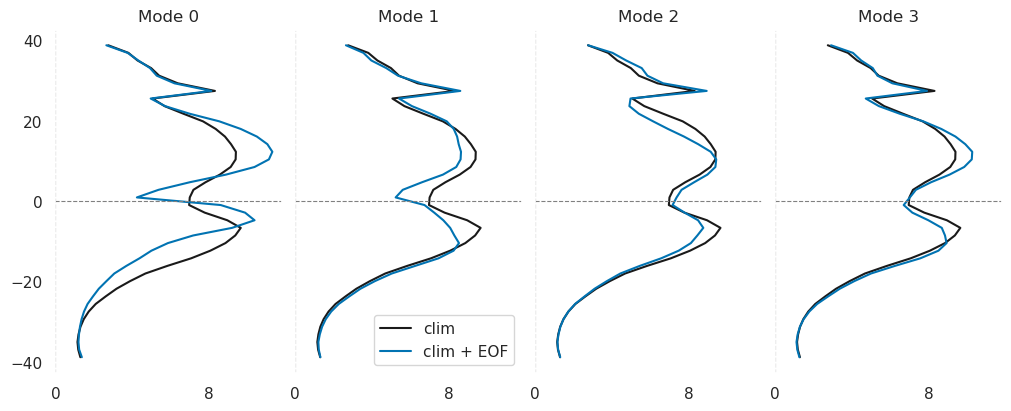

In [46]:
# specify EOF scale
EOF_SCALE = -2


fig, axs = plt.subplots(1, 4, figsize=(10, 4), layout="constrained")

for i, ax in enumerate(axs):

    ax.set_title(f"Mode {i}")

    ## plot clim
    ax.plot(Y_clim, comps.latitude, c="k", label="clim")

    ## plot clim + eof
    total = Y_clim + EOF_SCALE * comps.isel(mode=i)
    ax.plot(total, comps.latitude, label="clim + EOF")

for ax in axs:
    ax.set_yticks([])
    ax.axhline(0, ls="--", c="gray", lw=0.8)


axs[1].legend()
axs[0].set_yticks([-40, -20, 0, 20, 40])
src.utils.add_vticks(axs, xlines=[0], xticks=[0, 8])
src.utils.set_lims(axs)

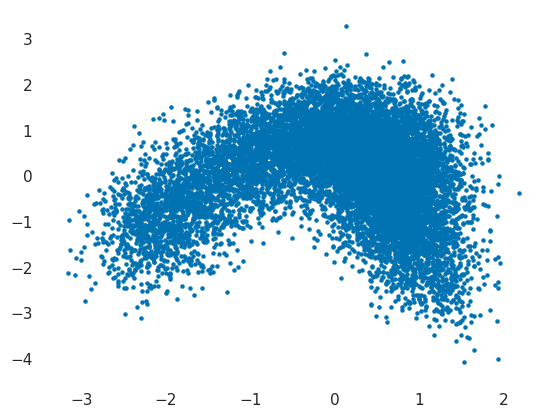

In [47]:
plt.scatter(
    scores_norm.isel(mode=0),
    scores_norm.isel(mode=1),
    s=5,
)

### Try low-pass filtering

In [48]:
## get total precip
pr_meri_total = pr_meri["forced"] + pr_meri["anom"]
Y = pr_meri_total.sel(time=slice("0900-01", "1849-12"))

## center
Y_bar = Y.groupby("time.month").mean(["time", "member"])
Y = Y.groupby("time.month") - Y_bar

## weight by cos lat
W = src.utils.get_coslat_weights(Y)
Y = Y * W

In [49]:
import xeofs as xe

## specs for EOFs
eofs_kwargs = dict(n_modes=20, standardize=False, use_coslat=False, center=False)

## initialize EOF model
eofs = xe.single.EOF(**eofs_kwargs)

## compute
eofs.fit(Y, dim=["time", "member"])

## extract components
N = int(len(Y.member) * len(Y.time))
Q = eofs.scores(normalized=True)
Z = eofs.components(normalized=True)
sigma = np.sqrt(N * eofs.explained_variance())

## merge data
eofs_ = xr.merge(
    [
        Z.rename("Z"),
        sigma.rename("sigma"),
        Q.rename("Q"),
        W.rename("W"),
    ]
)

In [50]:
## compute inner products
n_testmode = 10
idx = dict(mode=slice(None, n_testmode))
QtQ = xr.dot(
    eofs_["Q"].isel(idx),
    eofs_["Q"].isel(idx).rename({"mode": "mode_out"}),
    dims=["member", "time"],
)

ZtZ = xr.dot(
    eofs_["Z"].isel(idx).fillna(0),
    eofs_["Z"].isel(idx).fillna(0).rename({"mode": "mode_out"}),
    dims=["latitude"],
)

## check they're identities
eye = np.eye(n_testmode)
print(np.allclose(ZtZ.values, eye))
print(np.allclose(QtQ.values, eye))

### check we can reconstruct the data
idx = dict(time=slice(None, 30))

## reconstruct using package and custom
gt = Y.isel(idx)
r1 = xr.dot(eofs_["Z"], eofs_["sigma"], eofs_["Q"].isel(idx), dim="mode")

## check reconstruction close to original
print(f"{xr.corr(gt, r1).values.item():.6f}")

True
True
0.996961


In [51]:
from scipy.signal import butter, lfilter, freqz, filtfilt


def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype="low", analog=False)
    return b, a


def butter_lowpass_filter(data, cutoff, fs, order=5, axis=-1):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data, axis=axis)
    return y.squeeze()

In [52]:
## do low-pass filtering
Qtilde = copy.deepcopy((eofs_["Q"]).transpose(..., "time"))
Qtilde.values = butter_lowpass_filter(
    Qtilde.values[None, :], cutoff=1 / 25, fs=12, axis=-1
)
eofs_["Qtilde"] = Qtilde

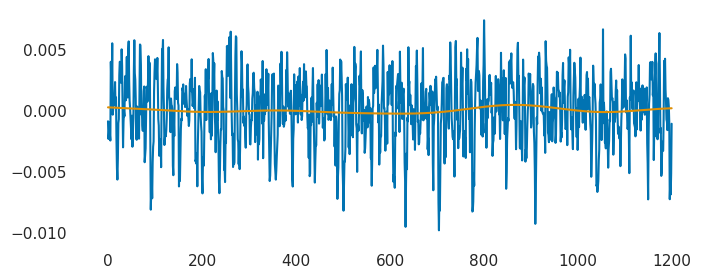

In [53]:
## plot results
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(eofs_["Q"].isel(mode=0, member=0, time=slice(None, 100 * 12)))
ax.plot(eofs_["Qtilde"].isel(mode=0, member=0, time=slice(None, 100 * 12)))

plt.show()

In [54]:
## covariance
nsamp = len(eofs_.time) * len(eofs_.member)
QtQ = (
    1
    / (nsamp - 1)
    * (eofs_["Qtilde"] * eofs_["Qtilde"].rename({"mode": "mode_"})).sum(
        ["time", "member"]
    )
)

## eigendecomp
Lambda_sqr, U = np.linalg.eigh(QtQ.values)
U = U[:, ::-1]
Lambda_sqr = Lambda_sqr[::-1]

## put in xarray dataset
eofs_tilde = xr.Dataset(
    data_vars=dict(
        U=(("mode", "mode_tilde"), U),
        Lambda=("mode_tilde", np.sqrt(Lambda_sqr)),
    ),
    coords=dict(mode=eofs_.mode.values, mode_tilde=eofs_.mode.values),
)

## get timeseries timeseries
eofs_tilde["tk"] = xr.dot(eofs_tilde["U"], eofs_["Q"], dim="mode")
eofs_tilde["tk_tilde"] = xr.dot(eofs_tilde["U"], eofs_["Qtilde"], dim="mode")

# get patterns
eofs_tilde["P"] = xr.dot(
    eofs_["Z"].fillna(0),
    eofs_["sigma"],
    eofs_tilde["U"],
    dim="mode",
)

## test a different way of computing Qbar, tk, P
eofs_tilde["P_test"] = xr.dot(Y, eofs_tilde["tk"], dim=["time", "member"])

## check tk's are orthgonal
TtT = xr.dot(
    eofs_tilde["tk"],
    eofs_tilde["tk"].rename({"mode_tilde": "mode"}),
    dim=["time", "member"],
)

## do tests
print(np.allclose(eofs_tilde["P"], eofs_tilde["P_test"]))
print(np.allclose(TtT.values, np.eye(TtT.shape[0])))

True
True


#### Plot structure of EOFs

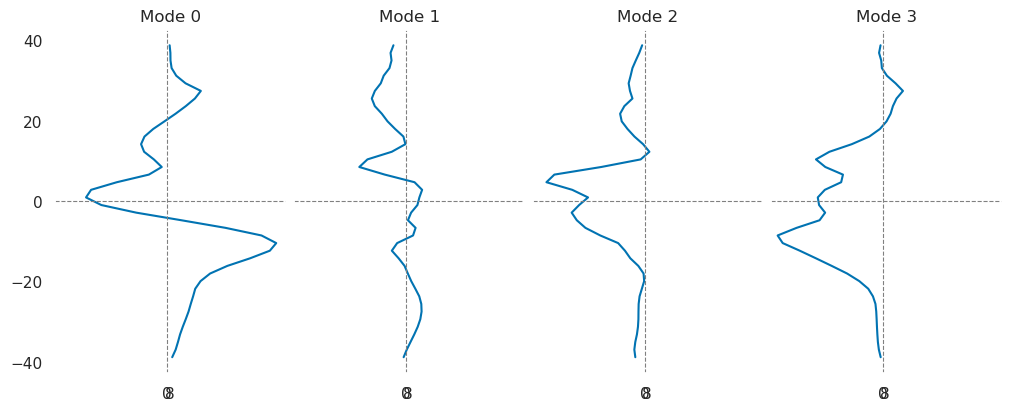

In [55]:
# specify EOF scale
EOF_SCALE = -2


fig, axs = plt.subplots(1, 4, figsize=(10, 4), layout="constrained")

for i, ax in enumerate(axs):

    ax.set_title(f"Mode {i}")

    ax.plot(eofs_tilde["P"].isel(mode_tilde=i), eofs_tilde.latitude)

for ax in axs:
    ax.set_yticks([])
    ax.axhline(0, ls="--", c="gray", lw=0.8)


axs[0].set_yticks([-40, -20, 0, 20, 40])
src.utils.add_vticks(axs, xlines=[0], xticks=[0, 8])
src.utils.set_lims(axs)

#### Timeseries

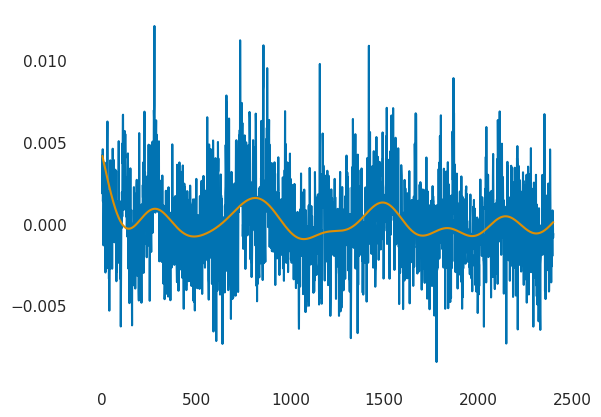

In [56]:
plt.plot(eofs_tilde["tk"].isel(member=0, mode_tilde=0, time=slice(200 * 12)))
plt.plot(eofs_tilde["tk_tilde"].isel(member=0, mode_tilde=0, time=slice(200 * 12)))

#### Compare to AAM

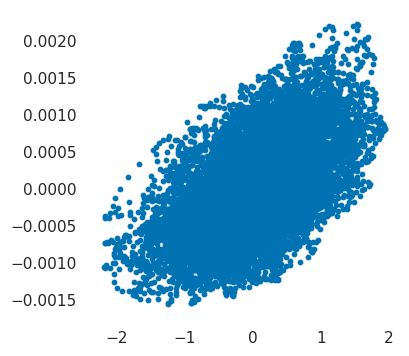

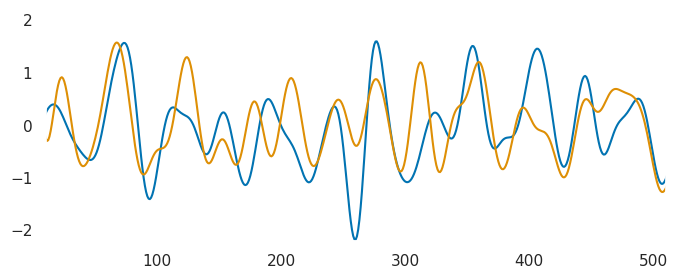

In [57]:
## annual average
tk_ann = eofs_tilde["tk_tilde"].resample({"time": "YS"}).mean()

## scatter
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(
    aam.sel(y0=slice(900, 1849)).isel(y0=slice(10, None)).transpose("member", "y0"),
    tk_ann.isel(mode_tilde=0).isel(time=slice(10, None)).transpose("member", "time"),
    s=10,
)

plt.show()

## timeseries
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(aam.sel(y0=slice(900, 1849)).isel(member=0), label="AAM")
ax.plot(tk_ann.isel(mode_tilde=0, member=0) * 1e3, label="Custom")
ax.set_ylim([-2.2, 2.2])
ax.set_xlim([10, 510])
plt.show()

#### Plot cov. w/SST

In [67]:
def prep_spatial(x):
    """prep spatial data for regression"""
    t_idx = dict(time=slice("0900-01", "1849-12"))
    x_total = x["forced"].sel(t_idx) + x["anom"].sel(t_idx)
    x_total = x_total - x_total.mean(["time", "member"])
    x_total = x_total.assign_coords({"time": eofs_tilde.time})

    ## annual mean
    x_total_ann = x_total.groupby("time.year").mean()
    return x_total_ann.fillna(0)

In [68]:
## annual mean
sst_total_ann = prep_spatial(sst)
pr_total_ann = prep_spatial(pr)
tk_ann = eofs_tilde["tk"].groupby("time.year").mean()

## compute SST pattern)
P_sst = xr.dot(
    sst_total_ann, tk_ann.isel(mode_tilde=slice(None, 3)), dim=["year", "member"]
)
P_pr = xr.dot(
    pr_total_ann, tk_ann.isel(mode_tilde=slice(None, 3)), dim=["year", "member"]
)

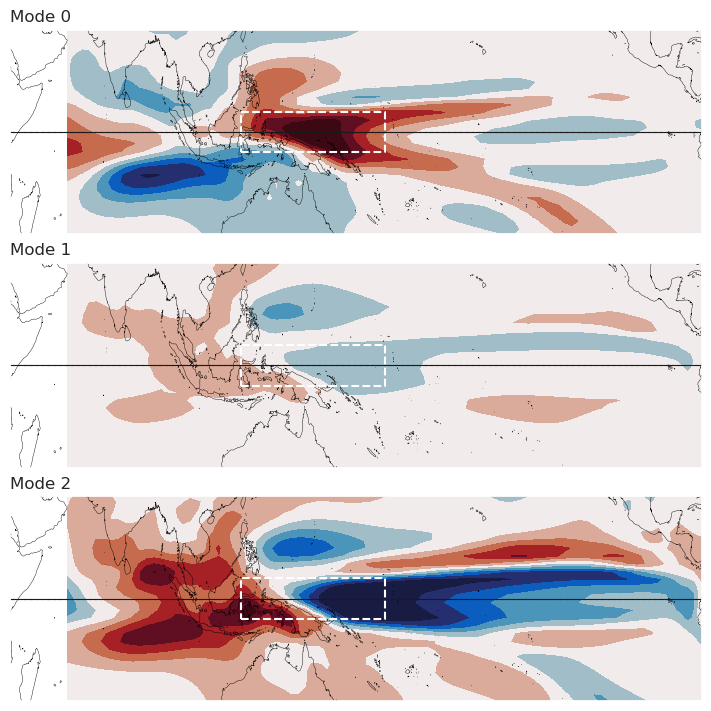

In [72]:
## specify plot data and interval
# p, DX = -sst_patterns.isel(mode=0), 0.25
# p, DX = P_sst, 2e0
p, DX = -P_pr, 5e0


fig = plt.figure(figsize=(7, 7), layout="constrained")
format_func = lambda ax,: src.utils.plot_setup_pac(ax, max_lat=25, lon_range=(40, 280))
axs = src.utils.subplots_with_proj(fig, nrows=3, ncols=1, format_func=format_func)


for j in range(3):
    cp = plot_sst(axs[j, 0], p.isel(mode_tilde=j), dx=DX)
    axs[j, 0].set_title(f"Mode {j}", loc="left")

## add labels
# add_gridlines(axs)
bbox = dict(boxstyle="round", facecolor="white", alpha=1)
legend_kwargs = dict(x=0.01, y=0.02, fontdict=dict(size=12, color="gray"), bbox=bbox)
for ax in axs.flatten():
    ax.set_aspect("auto")
    src.utils.plot_box(ax, lons=[120, 170], lats=[-5, 5], c="w", ls="--")
    src.utils.plot_box(ax, lons=[40, 280], lats=[-1e-3, 1e-3], c="k", ls="--", lw=0.8)

## colorbars
cb_kwargs = dict(label=r"$^{\circ}$C", pad=0.03)
plt.show()

Scratch

In [ ]:
## get principal components (normalized so that q.T@q=1)
Q = scores_norm / np.sqrt(N)

## check normalization
print(np.allclose(np.ones(10), (Q**2).sum(["member", "y0"]).values))

In [ ]:
import scipy.signal

# def make_lanczos_filter(cutoff, fs, order=5):
#     nyq = 0.5 * fs
#     normal_cutoff = cutoff / nyq
#     b, a = butter(order, normal_cutoff, btype="low", analog=False)
#     return b, a


# def apply_lanczos_filter(data, cutoff, fs=1):
#     b, a = butter_lowpass(cutoff, fs, order=order)
#     y = filtfilt(b, a, data, axis=1)
#     return y

In [ ]:
help(scipy.signal.windows.lanczos)

In [ ]:
help(scipy.signal.filtfilt)

In [ ]:
help(scipy.signal.sosfiltfilt)